# New Zealand Invasives Addax Data Science V1 (NZI-ADSV1) Sagemaker Serverless Deployment

This notebook deploys the New Zealand Invasives Addax Data Science V1 classifier to a Sagemaker serverless endpoint. It is intended to be run in a SageMaker Notebook instance on the conda_pytorch_p10 kernel.

## Setup

In [1]:
import boto3
import sagemaker
from sagemaker import get_execution_role
import time
import json
import base64
from datetime import datetime

Unable to load JumpStart region config.
Traceback (most recent call last):
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/jumpstart/constants.py", line 69, in _load_region_config
    with open(filepath) as f:
FileNotFoundError: [Errno 2] No such file or directory: '/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/jumpstart/region_config.json'


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


## Initialize AWS Session

In [2]:
sess = boto3.Session()
sm = sess.client('sagemaker')
region = sess.region_name
account = boto3.client('sts').get_caller_identity().get('Account')

## Get IAM Role

Note: Ensure the IAM role has:

- `AmazonS3FullAccess`
- `AmazonSageMakerFullAccess`

In [4]:
role = sagemaker.get_execution_role()
print(f"Using role: {role}")

Using role: arn:aws:iam::830244800171:role/service-role/AmazonSageMaker-ExecutionRole-20210125T212674


## Create ECR Repository

In [5]:
# Create ECR repository if it doesn't exist
registry_name = "nzi-adsv1-sagemaker-serverless"
ecr = boto3.client('ecr')

try:
    ecr.create_repository(repositoryName=registry_name)
except ecr.exceptions.RepositoryAlreadyExistsException:
    print("ECR repository already exists")
    pass

ECR repository already exists


## Build and upload container

Builds the the inference container with nzi-adsv1 and the sagemaker handler and uploads it to ECR.  This step takes several minutes after it prints the 'Login Succeeded' message.  Be patient and trust the process.

In [6]:
# flag to avoid timely image builds
should_create = True

if should_create:
    # Get auth token and login to ECR
    !aws ecr get-login-password --region {region} | docker login --username AWS --password-stdin {account}.dkr.ecr.{region}.amazonaws.com
    
    # Build container
    !docker build -q -t {registry_name} -f Dockerfile .
    
    # Tag and push to ECR
    image_uri = f"{account}.dkr.ecr.{region}.amazonaws.com/{registry_name}:latest"
    !docker tag {registry_name} {image_uri}
    !docker push {image_uri}
    
    print(f"Container pushed to: {image_uri}")

WARNING! Your password will be stored unencrypted in /home/ec2-user/.docker/config.json.
Configure a credential helper to remove this warning. See
https://docs.docker.com/engine/reference/commandline/login/#credentials-store

Login Succeeded
sha256:d019c73a6916f1e7effde53eddc15a367fb18dd8f5562c8a043043bdee02e459
The push refers to repository [830244800171.dkr.ecr.us-west-2.amazonaws.com/nzi-adsv1-sagemaker-serverless]

bf18a086: Preparing 
50944b0e: Preparing 
ae06c0ee: Preparing 
c926a435: Preparing 
b0293fe1: Preparing 
32ae2642: Preparing 
207b52a4: Preparing 
143f3d7f: Preparing 
2b569c3a: Preparing 
latest: digest: sha256:4cb9890e0031a636bbb3741d7fc0bdfac9815488a614b58563e8ff7ffa7eec6d size: 2418
Container pushed to: 830244800171.dkr.ecr.us-west-2.amazonaws.com/nzi-adsv1-sagemaker-serverless:latest


## Create Sagemaker Model

In [7]:
model_prefix = "nzi-adsv1"

# Check if model already exists
model_already_created = False
for model_def in sm.list_models()['Models']:
    if model_prefix == model_def['ModelName']:
        create_model_response = model_def
        model_already_created = True

# Create model if it doesn't exist
if not model_already_created:
    create_model_response = sm.create_model(
        ModelName=model_prefix,
        ExecutionRoleArn=role,
        PrimaryContainer={
            "Image": image_uri,
            "Environment": {
                "SAGEMAKER_PROGRAM": "serve.py"
            }
        }
    )

print(f"Model ARN: {create_model_response['ModelArn']}")

Model ARN: arn:aws:sagemaker:us-west-2:830244800171:model/nzi-adsv1


## Create Sagemaker realtime endpoint config

In [9]:
# Create realtime and batch endpoint configuration
realtime_endpoint_config_name = f"{model_prefix}-realtime-config"

realtime_endpoint_config_response = sm.create_endpoint_config(
    EndpointConfigName=realtime_endpoint_config_name,
    ProductionVariants=[
        {
            "ModelName": model_prefix,
            "VariantName": "AllTraffic",
            "ServerlessConfig": {
                "MemorySizeInMB": 6144,  # 6GB memory
                "MaxConcurrency": 20       # Maximum concurrent invocations
            }
        }
    ]
)
print(f"Realtime endpoint config ARN: {realtime_endpoint_config_response['EndpointConfigArn']}")

Realtime endpoint config ARN: arn:aws:sagemaker:us-west-2:830244800171:endpoint-config/nzi-adsv1-realtime-config


## Create realtime endpoint

In [10]:
# Create realtime endpoint
realtime_endpoint_name = f"{model_prefix}-concurrency-20"
create_realtime_endpoint_response = sm.create_endpoint(
    EndpointName=realtime_endpoint_name,
    EndpointConfigName=realtime_endpoint_config_name
)

print(f"Endpoint ARN: {create_realtime_endpoint_response['EndpointArn']}")

# Wait for endpoint creation
resp = sm.describe_endpoint(EndpointName=realtime_endpoint_name)
realtime_status = resp['EndpointStatus']
print(f"Status: {realtime_status}")

while realtime_status == 'Creating':
    time.sleep(60)
    resp = sm.describe_endpoint(EndpointName=realtime_endpoint_name)
    realtime_status = resp['EndpointStatus']
    print(f"Status: {realtime_status}")
    if realtime_status == 'Failed':
        realtime_failure_reason = resp.get('FailureReason', 'No failure reason provided')
        print(f"Realtime endpoint deployment failed: {realtime_failure_reason}")
        break

# Get CloudWatch logs for the endpoint
logs = boto3.client('logs')

print(f"Realtime Arn: {resp['EndpointArn']}")
print(f"Realtime endpoint final status: {realtime_status}")
if realtime_status == 'Failed':
    realtime_log_group = f"/aws/sagemaker/Endpoints/{realtime_endpoint_name}"
    try:
        log_streams = logs.describe_log_streams(
            logGroupName=realtime_log_group,
            orderBy='LastEventTime',
            descending=True,
            limit=1
        )
        if log_streams['logStreams']:
            stream = log_streams['logStreams'][0]
            print(f"\nLog stream: {stream['logStreamName']}")
            realtime_events = logs.get_log_events(
                logGroupName=realtime_log_group,
                logStreamName=stream['logStreamName'],
                startFromHead=True
            )
            for event in realtime_events['events']:
                print(event['message'])
    except Exception as e:
        print(f"Error fetching logs: {str(e)}")

Endpoint ARN: arn:aws:sagemaker:us-west-2:830244800171:endpoint/nzi-adsv1-concurrency-20
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: InService
Realtime Arn: arn:aws:sagemaker:us-west-2:830244800171:endpoint/nzi-adsv1-concurrency-20
Realtime endpoint final status: InService


## Create batch endpoint config¶

Flip the create_batch_endpoint_config flag if not needed.

In [11]:
batch_endpoint_config_name = f"{model_prefix}-batch-config"

# Disable batch endpoint config creation if not needed
create_batch_endpoint_config = True

if create_batch_endpoint_config:
    batch_endpoint_config_response = sm.create_endpoint_config(
        EndpointConfigName=batch_endpoint_config_name,
        ProductionVariants=[
            {
                "ModelName": model_prefix,
                "VariantName": "AllTraffic",
                "ServerlessConfig": {
                    "MemorySizeInMB": 6144,  # 6GB memory
                    "MaxConcurrency": 80       # Maximum concurrent invocations
                }
            }
        ]
    )
    print(f"Batch endpoint config ARN: {batch_endpoint_config_response['EndpointConfigArn']}")

Batch endpoint config ARN: arn:aws:sagemaker:us-west-2:830244800171:endpoint-config/nzi-adsv1-batch-config


## Create batch endpoint

In [12]:
# Create batch endpoint
create_batch_endpoint = True

if create_batch_endpoint:
    batch_endpoint_name = f"{model_prefix}-concurrency-80"
    create_batch_endpoint_response = sm.create_endpoint(
        EndpointName=batch_endpoint_name,
        EndpointConfigName=batch_endpoint_config_name
    )
    
    print(f"Endpoint ARN: {create_batch_endpoint_response['EndpointArn']}")
    
    # Wait for endpoint creation
    resp = sm.describe_endpoint(EndpointName=batch_endpoint_name)
    batch_status = resp['EndpointStatus']
    print(f"Status: {batch_status}")
    
    while batch_status == 'Creating':
        time.sleep(60)
        resp = sm.describe_endpoint(EndpointName=batch_endpoint_name)
        batch_status = resp['EndpointStatus']
        print(f"Status: {batch_status}")
        if batch_status == 'Failed':
            batch_failure_reason = resp.get('FailureReason', 'No failure reason provided')
            print(f"Batch endpoint deployment failed: {batch_failure_reason}")
            break
    
    # Get CloudWatch logs for the endpoint
    logs = boto3.client('logs')
    
    print(f"Batch Arn: {resp['EndpointArn']}")
    print(f"Batch endpoint final status: {batch_status}")
    if batch_status == 'Failed':
        batch_log_group = f"/aws/sagemaker/Endpoints/{batch_endpoint_name}"
        try:
            log_streams = logs.describe_log_streams(
                logGroupName=batch_log_group,
                orderBy='LastEventTime',
                descending=True,
                limit=1
            )
            if log_streams['logStreams']:
                stream = log_streams['logStreams'][0]
                print(f"\nLog stream: {stream['logStreamName']}")
                batch_events = logs.get_log_events(
                    logGroupName=batch_log_group,
                    logStreamName=stream['logStreamName'],
                    startFromHead=True
                )
                for event in batch_events['events']:
                    print(event['message'])
        except Exception as e:
            print(f"Error fetching logs: {str(e)}")

Endpoint ARN: arn:aws:sagemaker:us-west-2:830244800171:endpoint/nzi-adsv1-concurrency-80
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: InService
Batch Arn: arn:aws:sagemaker:us-west-2:830244800171:endpoint/nzi-adsv1-concurrency-80
Batch endpoint final status: InService


## Validate detections

In [13]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import boto3
import base64
from io import BytesIO

## Visualization

In [14]:
def draw_classifications(image, predictions):
    """Draw bounding boxes and labels on the image."""
    image_draw = image.copy()
    draw = ImageDraw.Draw(image_draw)
    width, height = image.size

    for det in predictions:
        x1 = det['x1'] * width
        y1 = det['y1'] * height
        x2 = det['x2'] * width
        y2 = det['y2'] * height

        draw.rectangle([x1, y1, x2, y2], outline='blue', width=3)
        label = f"{det['class']}: {det['confidence']:.10f}"
        draw.text((x1, y1-15), label, fill='blue')

    return image_draw

## Load image

This is a helper for loading an image from local file.  Useful for validating multiple images.

In [15]:
def load_image(image_path):
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    image_b64 = base64.b64encode(image_bytes)
    return Image.open(image_path), image_b64

## Get detections using Megadetector V1000

This invokes the Megadetector V1000 Sagemaker endpoint and then processes the detections to remove non-animal detections and detections below the default `0.35` confidence threshold.  This mimics a common automation rule setup in Animl.

In [16]:
# Helper method to get Megadetector detections
def get_detections(image_b64):
    runtime = boto3.client('sagemaker-runtime', region_name='us-west-2')

    detection_response = runtime.invoke_endpoint(
        EndpointName='mdv1000-0-0-redwood-concurrency-20',
        ContentType='application/octet-stream',  # or 'application/x-image'
        Body=image_b64  # or just image_bytes if not base64 encoding
    )

    # Get result
    detection_result = detection_response['Body'].read()
    detection_result = json.loads(detection_result)

    # Filter non-animals
    detection_result = [d for d in detection_result if d['class'] == 1]

    # Remove low confidence detections
    detection_result = [d for d in detection_result if d['confidence'] > 0.35]

    return detection_result

## Get classifications

This is a helper method to get classifications for Megadetector detections using the endpoint specified by `endpoint_name`

In [17]:
def get_classifications(endpoint_name, detections, image_b64):
    runtime = boto3.client('sagemaker-runtime', region_name='us-west-2')
    def classify_bbox(d):
        w = d['x2'] - d['x1']
        h = d['y2'] - d['y1']
        bbox = [d['x1'], d['y1'], w, h]
        classification_response = runtime.invoke_endpoint(
            EndpointName=endpoint_name,
            ContentType='application/json',
            Body=json.dumps({
                'bbox': bbox,
                'image': image_b64.decode('utf-8')
            })
        )

        classification_result = classification_response['Body'].read()
        classification_result = json.loads(classification_result)

        # Take only highest confidence for visualization
        highest_conf = max(classification_result.items(), key=lambda x: x[1])

        d['confidence'] = highest_conf[1]
        d['class'] = highest_conf[0]

        return d
    return [classify_bbox(detection) for detection in detections]

## Invoke realtime endpoint (after invoking Megadetector)

This performs several steps to validate realtime predictions:

- Loads an image from the specified `batch_image_path`
- Gets detections using the Megadetector endpoint
- Gets classifications for each filtered detection using the realtime nzi-adsv1 endpoint
- Draws the results to an annotated image for visual validation of the classifications

Loading image..
Getting detections..
Getting classifications for each detection..
Classifications: [
    {
        "x1": 0.1738,
        "y1": 0.2685,
        "x2": 0.7392000000000001,
        "y2": 0.579,
        "confidence": 0.999940037727356,
        "class": "mustelid"
    }
]
Visualizing results..


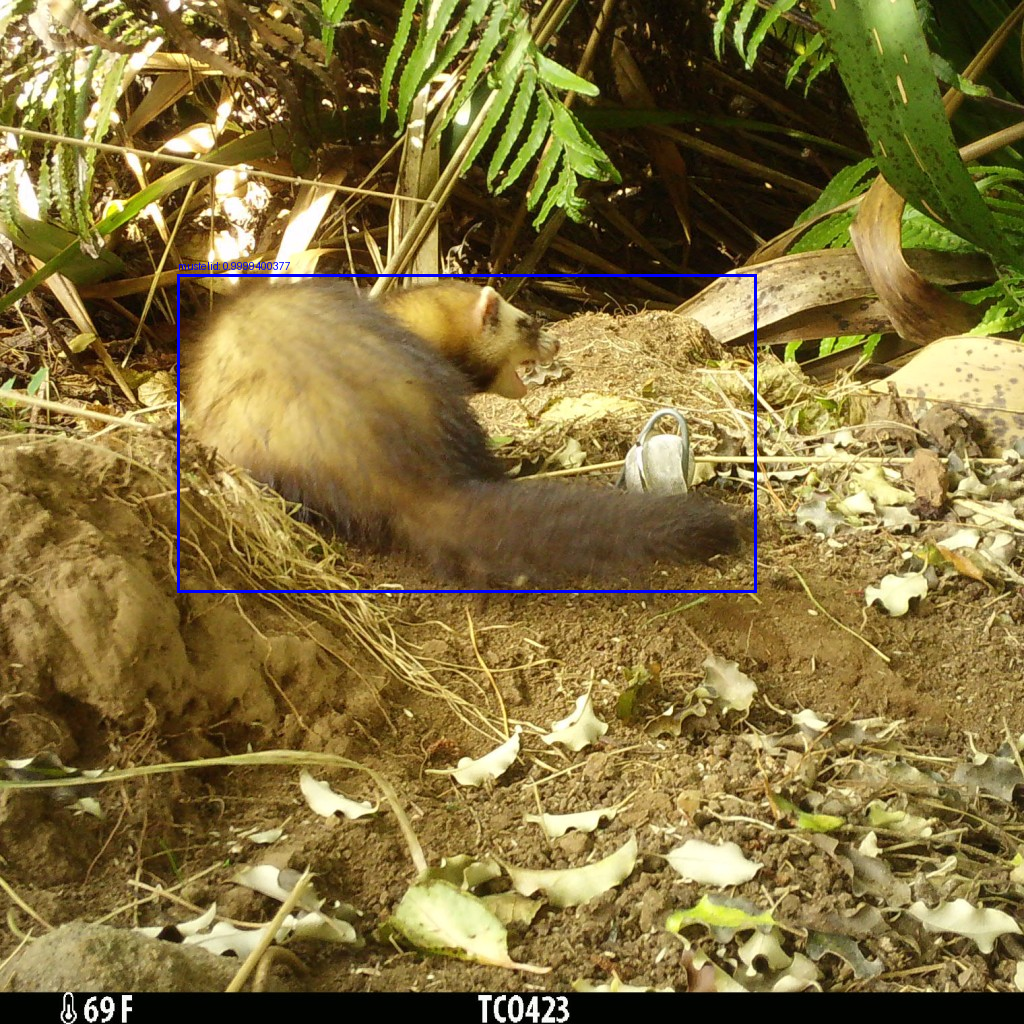

In [ ]:
# Setup realtime validation variables
rt_endpoint_name = 'nzi-adsv1-concurrency-20'
rt_image_path = 'local_validation/nzi-ads-validation/ferret.jpg'

# Load image
print('Loading image..')
rt_image, b64_rt_image = load_image(rt_image_path)

# Get detections
print('Getting detections..')
rt_detections = get_detections(b64_rt_image)

# Get classifications for detections
print('Getting classifications for each detection..')
rt_classifications = get_classifications(rt_endpoint_name, rt_detections, b64_rt_image)
print(f'Classifications: {json.dumps(rt_classifications, indent=4)}')

# Visualize classifications
print('Visualizing results..')
annotated_rt_image = draw_classifications(rt_image, rt_classifications)
annotated_rt_image.show()

## Invoke batch endpoint (after invoking Megadetector)

This performs several steps to validate batch predictions:

- Loads an image from the specified `batch_image_path`
- Gets detections using the Megadetector endpoint
- Gets classifications for each filtered detection using the batch nzi-adsv1 endpoint
- Draws the results to an annotated image for visual validation of the classifications

Loading image..
Getting detections..
Getting classifications for each detection..
Classifications: [
    {
        "x1": 0.5117,
        "y1": 0.1513,
        "x2": 0.9111,
        "y2": 0.7518,
        "confidence": 1.0,
        "class": "other bird"
    }
]
Visualizing results..


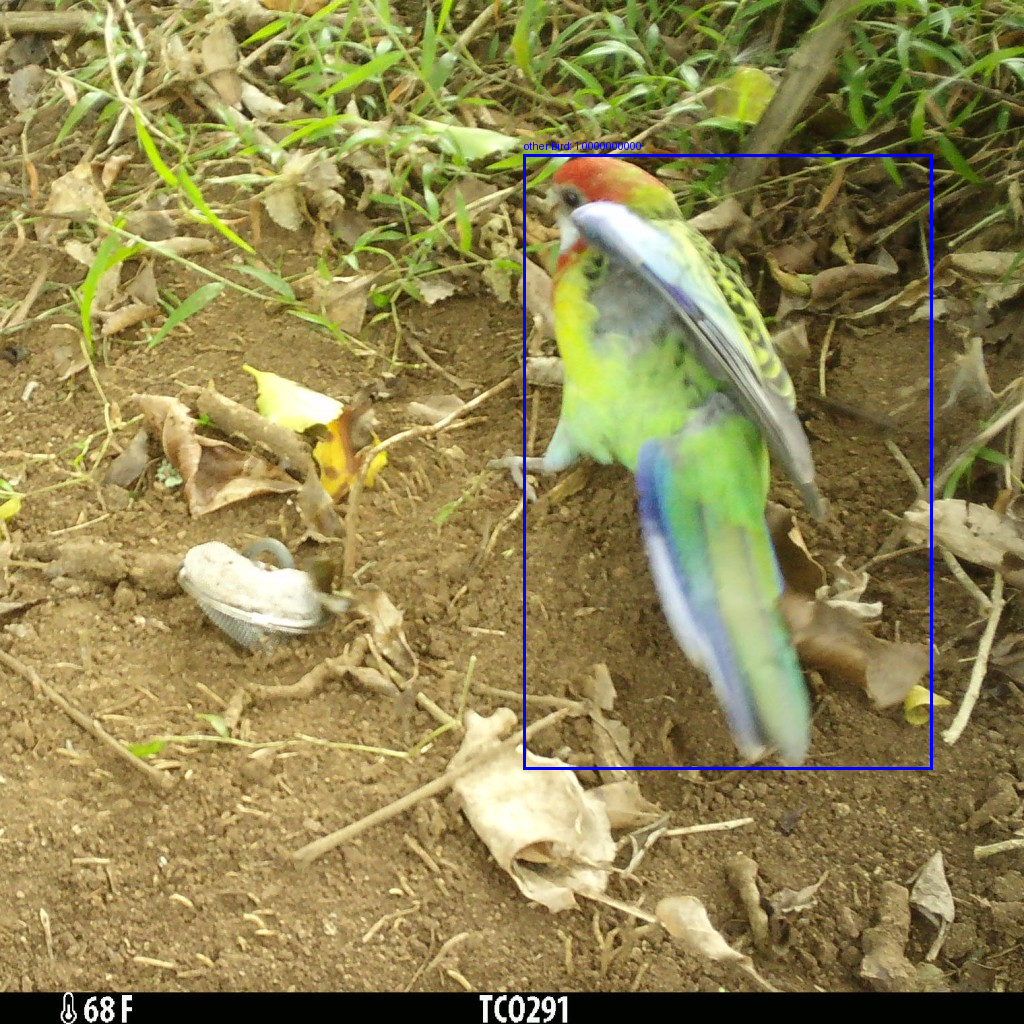

In [22]:
# Setup realtime validation variables
batch_endpoint_name = 'nzi-adsv1-concurrency-80'
batch_image_path = 'local_validation/nzi-ads-validation/rosella.jpg'

# Load image
print('Loading image..')
batch_image, b64_batch_image = load_image(batch_image_path)

# Get detections
print('Getting detections..')
batch_detections = get_detections(b64_batch_image)

# Get classifications for detections
print('Getting classifications for each detection..')
batch_classifications = get_classifications(batch_endpoint_name, batch_detections, b64_batch_image)
print(f'Classifications: {json.dumps(batch_classifications, indent=4)}')

# Visualize classifications
print('Visualizing results..')
annotated_batch_image = draw_classifications(batch_image, batch_classifications)
annotated_batch_image.show()

## Compare deployed results with Addax provided detection and classifications

Peter van Lunteren was generous enough to provide a validation set of images and classifications to ensure our deployed model is working as expected.

In [26]:
import math

runtime = boto3.client('sagemaker-runtime', region_name='us-west-2')

with open('local_validation/deployment_002/image_recognition_file.json') as td:
    ads_data = json.load(td)

ads_imgs_res = ads_data['images']
ads_class_mapping = ads_data['classification_categories']

for ads_img_res in ads_imgs_res:
    ads_img_name = ads_img_res['file']
    print(f'Evaluating {ads_img_name}..')
    ads_img, b64_ads_img = load_image(f'local_validation/deployment_002/{ads_img_name}')

    our_predictions = []
    for det_i, ads_det in enumerate(ads_img_res['detections']):
        ads_bbox = ads_det['bbox']
        
        ads_classifications = {}
        for c in ads_det['classifications']:
            ads_classifications[ads_class_mapping[c[0]]] = c[1]

        our_classification_res = runtime.invoke_endpoint(
            EndpointName='nzi-adsv1-concurrency-20',
            ContentType='application/json',
            Body=json.dumps({
                'bbox': ads_bbox,
                'image': b64_ads_img.decode('utf-8')
            })
        )

        our_classification_res = our_classification_res['Body'].read()
        our_classification_res = json.loads(our_classification_res)

        diff_count = 0
        for our_class, our_conf in our_classification_res.items():
            our_conf = round(our_conf, 5)
            ads_conf = ads_classifications[our_class]
            if not math.isclose(our_conf, ads_conf):
                diff_count += 1
                print(f'    - {our_class}.  Expected: {ads_conf} but got: {our_conf}')
        if diff_count > 0:
            print(f'Differences for detection {det_i} of {ads_img_name}')
        else:
            print(f'No differences for detection {det_i} of {ads_img_name}')
    print('')

Evaluating img_0001.jpg..
No differences for detection 0 of img_0001.jpg
No differences for detection 1 of img_0001.jpg

Evaluating img_0002.jpg..
No differences for detection 0 of img_0002.jpg
No differences for detection 1 of img_0002.jpg

Evaluating img_0003.jpg..
No differences for detection 0 of img_0003.jpg
No differences for detection 1 of img_0003.jpg

Evaluating img_0004.jpg..
No differences for detection 0 of img_0004.jpg

Evaluating img_0005.jpg..
No differences for detection 0 of img_0005.jpg

Evaluating img_0006.jpg..
No differences for detection 0 of img_0006.jpg

Evaluating img_0007.jpg..
No differences for detection 0 of img_0007.jpg

Evaluating img_0008.jpg..
No differences for detection 0 of img_0008.jpg

Evaluating img_0009.jpg..
No differences for detection 0 of img_0009.jpg

Evaluating img_0010.jpg..
No differences for detection 0 of img_0010.jpg
    - hedgehog.  Expected: 0.38641 but got: 0.3864
Differences for detection 1 of img_0010.jpg

Evaluating img_0011.jpg.